<a href="https://colab.research.google.com/github/ERUM-ROMESA/AI-ML-internship-2026/blob/main/first_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None)

df.columns = ['label', 'message']

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'SMSSpamCollection'

In [ ]:
import os

print(os.listdir())

['.config', 'sms+spam+collection.zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile('sms+spam+collection.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted!")

Extracted!


In [ ]:
import os

print(os.listdir())

['.config', 'sms+spam+collection.zip', 'readme', 'SMSSpamCollection', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None)

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [ ]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print(X_train.shape)

(4457, 7702)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9919282511210762


In [ ]:
message = ["Congratulations! You have won a free iPhone. Click here now!"]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam


In [ ]:
message = ["chatgpt helped me finish my first machine learning project today."]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


In [ ]:
message = ["Hey, are you coming to class tomorrow?"]

In [ ]:
message = ["Mom, I'll be home in 20 minutes."]

In [ ]:
message = ["You have won $1000 cash! Claim your prize now!"]

In [ ]:
message = ["URGENT! Your account has been selected for a reward. Click here."]

In [ ]:
message = ["ChatGPT helped me finish my first machine learning project today."]

In [ ]:
message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


In [ ]:
message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


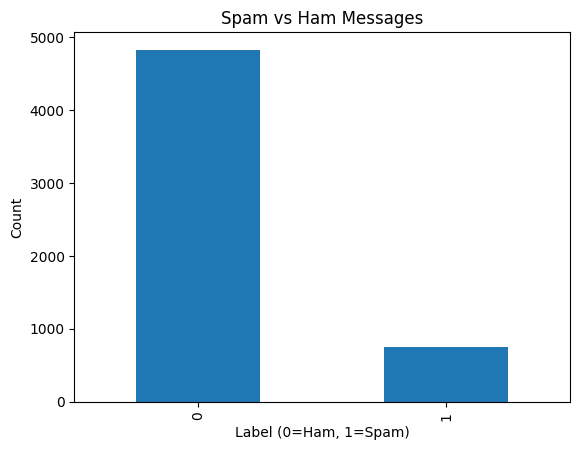

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Label (0=Ham, 1=Spam)")
plt.ylabel("Count")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[966   0]
 [  9 140]]


SMS Spam Detection using Machine Learning

# SMS Spam Detection using Machine Learning

## Objective
The goal of this project is to classify SMS messages as Spam or Ham using Machine Learning techniques.

## Technologies Used
- Python
- Pandas
- Scikit-learn
- Google Colab
- CountVectorizer
- Naive Bayes

## Results
The model achieved 99.2% accuracy on the test dataset.